In [19]:
from eeg_music.data import EEGMusicDataset
from pathlib import Path
ds =  EEGMusicDataset.load_ondisk(Path("./datasets/musing_preprocessed/musing_ica_8ch"))
len(ds)

240

In [21]:
splitted = ds.subject_wise_split(p_train=0.7, p_val=0.0)
train_ds, test_ds = splitted["train"], splitted["test"]
len(train_ds), len(test_ds)

(168, 72)

In [22]:
# train_ds[i].music_data.music_id.song_id is label
# train_ds[i].eeg_data.get_array().data is data

In [23]:
from fractions import Fraction
from eeg_music.data import ArrayStratifiedSamplingDataset

train_ds_strat = ArrayStratifiedSamplingDataset(train_ds, 10, trial_length_secs=Fraction(1, 1))
test_ds_strat =  ArrayStratifiedSamplingDataset(test_ds, 10, trial_length_secs=Fraction(1, 1))

In [24]:
import numpy as np
def create_X_y(dataset):
    X = []
    y = []
    for i in range(len(dataset)):
        sample = dataset[i]
        X.append(sample.eeg_data.get_array().data)
        y.append(sample.music_data.music_id.song_id - 1)
    return np.array(X), np.array(y)

X_train, y_train = create_X_y(train_ds_strat)
X_train.shape, y_train.shape

((1680, 40, 10), (1680,))

In [25]:
from eeg_music.data import RepeatedDataset

train_ds_repeated = RepeatedDataset(train_ds_strat, 10)
test_ds_repeated = RepeatedDataset(test_ds_strat, 10)

X_train, y_train = create_X_y(train_ds_repeated)
X_test, y_test = create_X_y(test_ds_repeated)

In [26]:
import numpy as np
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

# Flatten EEG data for traditional ML models (samples, channels, timepoints) -> (samples, features)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Training set: {X_train_flat.shape}, Labels: {y_train.shape}")
print(f"Test set: {X_test_flat.shape}, Labels: {y_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")

Training set: (16800, 400), Labels: (16800,)
Test set: (7200, 400), Labels: (7200,)
Number of classes: 12


In [37]:
# Train XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_xgb = xgb_model.predict(X_test_flat)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print(f"\nXGBoost Test Accuracy: {xgb_accuracy:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost...

XGBoost Test Accuracy: 0.1668

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.07      0.10       600
           1       0.25      0.38      0.30       600
           2       0.02      0.01      0.02       600
           3       0.54      0.32      0.40       600
           4       0.17      0.53      0.26       600
           5       0.14      0.15      0.15       600
           6       0.00      0.00      0.00       600
           7       0.16      0.14      0.15       600
           8       0.13      0.09      0.11       600
           9       0.22      0.16      0.18       600
          10       0.27      0.13      0.18       600
          11       0.01      0.01      0.01       600

    accuracy                           0.17      7200
   macro avg       0.18      0.17      0.15      7200
weighted avg       0.18      0.17      0.15      7200



In [28]:
# Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_flat)
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print(f"\nSVM Test Accuracy: {svm_accuracy:.4f}")
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

Training SVM...

SVM Test Accuracy: 0.1229

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.09      0.44      0.15       600
           1       0.21      0.35      0.26       600
           2       0.31      0.30      0.30       600
           3       0.00      0.00      0.00       600
           4       0.02      0.01      0.01       600
           5       0.00      0.00      0.00       600
           6       0.00      0.00      0.00       600
           7       0.20      0.29      0.24       600
           8       0.03      0.00      0.01       600
           9       0.01      0.00      0.00       600
          10       0.01      0.01      0.01       600
          11       0.09      0.07      0.08       600

    accuracy                           0.12      7200
   macro avg       0.08      0.12      0.09      7200
weighted avg       0.08      0.12      0.09      7200



In [29]:
# Train KNN
from sklearn.neighbors import KNeighborsClassifier
print("Training KNN...")
knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_flat, y_train)

# Predict and evaluate
y_pred_knn = knn_model.predict(X_test_flat)
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print(f"\nKNN Test Accuracy: {knn_accuracy:.4f}")
print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

Training KNN...

KNN Test Accuracy: 0.1374

KNN Classification Report:
              precision    recall  f1-score   support

           0       0.01      0.01      0.01       600
           1       0.27      0.28      0.28       600
           2       0.23      0.27      0.25       600
           3       0.08      0.09      0.08       600
           4       0.18      0.16      0.17       600
           5       0.14      0.10      0.12       600
           6       0.08      0.07      0.07       600
           7       0.30      0.23      0.26       600
           8       0.27      0.20      0.23       600
           9       0.09      0.07      0.08       600
          10       0.04      0.08      0.05       600
          11       0.08      0.09      0.09       600

    accuracy                           0.14      7200
   macro avg       0.15      0.14      0.14      7200
weighted avg       0.15      0.14      0.14      7200



In [30]:
# Compare results
print("\n" + "="*50)
print("COMPARISON")
print("="*50)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"SVM Accuracy:     {svm_accuracy:.4f}")
print(f"KNN Accuracy:     {knn_accuracy:.4f}")


COMPARISON
XGBoost Accuracy: 0.1668
SVM Accuracy:     0.1229
KNN Accuracy:     0.1374


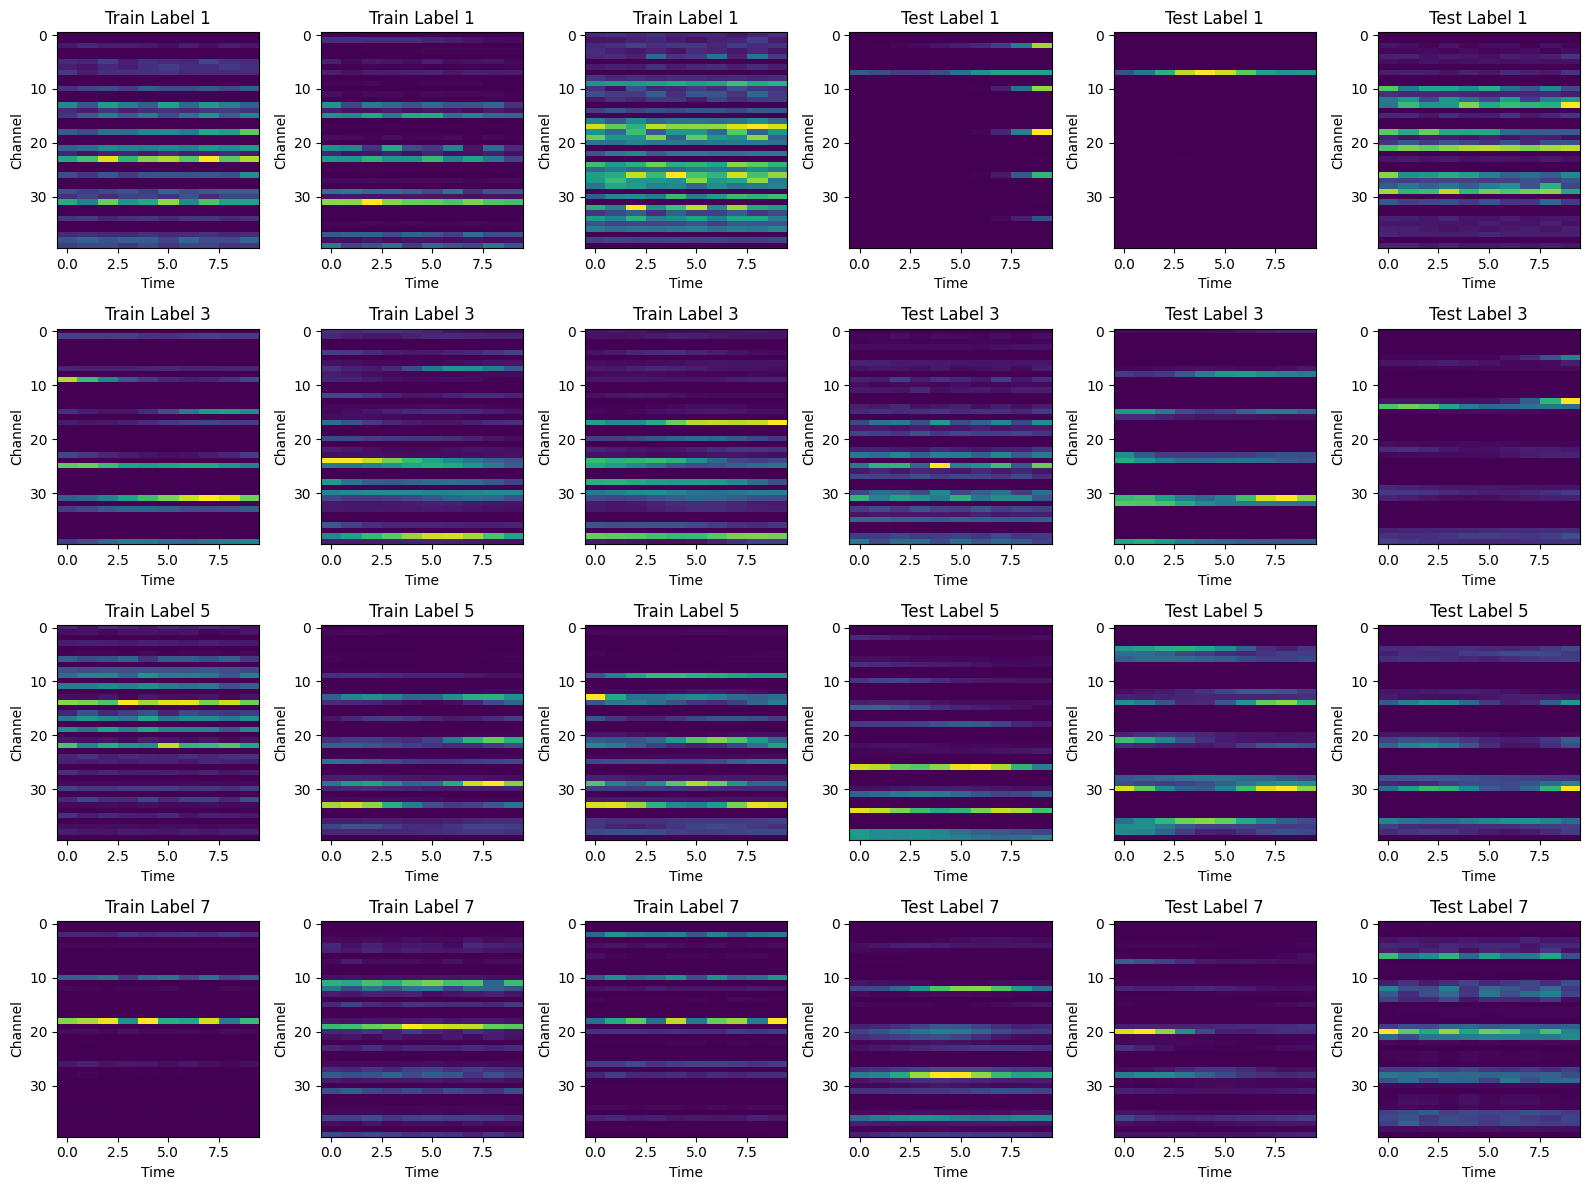

In [31]:
import matplotlib.pyplot as plt

labels_to_plot = [1, 3, 5, 7]
samples_per_label = 3

fig, axes = plt.subplots(len(labels_to_plot), 2*samples_per_label, figsize=(16, 12))

for row, label in enumerate(labels_to_plot):
    # Get train samples with this label
    train_label_indices = np.where(y_train == label)[0]
    train_sampled = np.random.choice(train_label_indices, min(samples_per_label, len(train_label_indices)), replace=False)
    
    # Get test samples with this label
    test_label_indices = np.where(y_test == label)[0]
    test_sampled = np.random.choice(test_label_indices, min(samples_per_label, len(test_label_indices)), replace=False)
    
    # Plot train samples (left side)
    for col, idx in enumerate(train_sampled):
        axes[row, col].imshow(X_train[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, col].set_title(f"Train Label {label}")
        axes[row, col].set_xlabel("Time")
        axes[row, col].set_ylabel("Channel")
    
    # Plot test samples (right side)
    for col, idx in enumerate(test_sampled):
        axes[row, samples_per_label + col].imshow(X_test[idx], aspect='auto', interpolation='nearest', cmap='viridis')
        axes[row, samples_per_label + col].set_title(f"Test Label {label}")
        axes[row, samples_per_label + col].set_xlabel("Time")
        axes[row, samples_per_label + col].set_ylabel("Channel")

plt.tight_layout()
plt.show()

In [32]:

train_ds_strat_2 = RepeatedDataset(ChangedArrayStratifiedSamplingDataset(train_ds, 10, trial_length_secs=Fraction(10, 1)),
    num_repeats=10
  )
len(train_ds_strat_2)
for i in range(1200):
  _ = train_ds_strat_2[i]


NameError: name 'ChangedArrayStratifiedSamplingDataset' is not defined

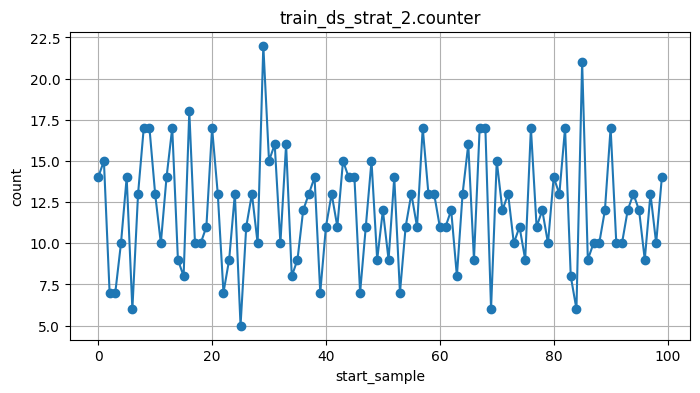

In [ ]:

import numpy as np
import matplotlib.pyplot as plt

counter = train_ds_strat_2.dataset.counter

xs = np.array(sorted(counter.keys()))
ys = np.array([counter[x] for x in xs])
plt.figure(figsize=(8, 4))
plt.plot(xs, ys, "-o")
plt.xlabel("start_sample")
plt.ylabel("count")
plt.title("train_ds_strat_2.counter")
plt.grid(True)
plt.show()

In [ ]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from fractions import Fraction
from pathlib import Path
from typing import (
  Dict,
  Optional,
  Union,
  Callable,
  TypeVar,
  Generic,
  List,
  TypedDict,
  Any,
  cast,  # added
)
import numpy as np
from numpy.typing import NDArray
from mne.io import BaseRaw
import pandas as pd
from scipy.io import wavfile
import mne
from pandas import DataFrame, Index
import json
import shutil
import torch.utils.data as torchdata
from speechbrain.dataio.batch import PaddedBatch
import pydub
import librosa
import librosa.display as lbd
import matplotlib.pyplot as plt

from eeg_music.data import ArrayEeg, EegData, MelRaw, MusicData, MusingMusicIdData, NoteOnsets, TrialData, WavRAW, int_or_err, MusicRef



class ChangedArrayStratifiedSamplingDataset(EEGMusicDataset):
  """
  Wrapper over ds.

  Similar to StratifiedSamplingDataset but:
  - Expects EEG to be ArrayEeg (numpy array based)
  - Passes music data as-is without modifications
  - Only applies stratified sampling to EEG
  """

  def __init__(
    self,
    base_dataset: EEGMusicDataset,
    n_strata: int,
    trial_length_secs: Fraction,
  ):
    self.ds = base_dataset
    self.n_strata = n_strata
    self.trial_length_secs: Fraction = trial_length_secs
    self.counter = dict()

  @property
  def df(self) -> pd.DataFrame:
    return self.ds.df

  @df.setter
  def df(self, value: pd.DataFrame) -> None:
    self.ds.df = value

  @property
  def music_collection(self) -> Dict[MusicRef, MusicData]:  # type: ignore[reportIncompatibleVariableOverride]
    return self.ds.music_collection

  @music_collection.setter
  def music_collection(self, value: Dict[MusicRef, MusicData]):  # type: ignore[reportIncompatibleVariableOverride]
    self.ds.music_collection = value

  def __len__(self) -> int:
    return len(self.ds) * self.n_strata

  def __getitem__(self, idx: int) -> TrialData[ArrayEeg, MusicData]:
    """
    Return a portion of a trial with EEG and music trimmed using stratified sampling.
    """
    trial_index = idx // self.n_strata
    trial: TrialData[EegData, MusicData] = self.ds.__getitem__(trial_index)
    stratum_index = idx % self.n_strata

    # Get ArrayEeg
    array_eeg = trial.eeg_data.get_array()  # type: ignore[reportAttributeAccessIssue]

    e_len = array_eeg.length_seconds()
    sfreq = array_eeg.sfreq

    # Calculate stratified sampling bounds
    n_starts = int((e_len - self.trial_length_secs) * sfreq)
    new_length_samples = int_or_err(self.trial_length_secs * Fraction(sfreq))
    n_starts_exact = array_eeg.data.shape[1] - new_length_samples + 1

    s_start = (n_starts * stratum_index) // self.n_strata
    s_end = (n_starts * (stratum_index + 1)) // self.n_strata
    random_start = np.random.randint(s_start, min(s_end, n_starts_exact))

    if random_start in self.counter:
      self.counter[random_start] += 1
    else:
      self.counter[random_start] = 1

    # Trim EEG data
    trimmed_data = array_eeg.data[:, random_start : random_start + new_length_samples]
    trimmed_eeg = ArrayEeg(data=trimmed_data, ch_names=array_eeg.ch_names, sfreq=sfreq)

    # Trim music data to match EEG slice
    music_obj = trial.music_data.get_music()
    match music_obj:
      case WavRAW(raw_data, sample_rate):
        new_length_samples_music = int_or_err(self.trial_length_secs * sample_rate)
        tot_m = music_obj.length_samples()
        random_start_music = round((tot_m * random_start) / n_starts_exact)
        random_start_music = min(random_start_music, tot_m - new_length_samples_music)
        return_music = WavRAW(
          raw_data=raw_data[
            random_start_music : random_start_music + new_length_samples_music
          ],
          sample_rate=sample_rate,
        )

      case MelRaw(mel, sample_rate, hop_length, fmin, fmax, to_db):
        new_length_samples_music = int_or_err(
          self.trial_length_secs * sample_rate / hop_length
        )
        tot_m = music_obj.mel.shape[-1]
        random_start_music = round((tot_m * random_start) / n_starts_exact)
        random_start_music = min(random_start_music, tot_m - new_length_samples_music)
        return_music = MelRaw(
          mel=mel[
            :, random_start_music : random_start_music + new_length_samples_music
          ],
          sample_rate=sample_rate,
          hop_length=hop_length,
          fmin=fmin,
          fmax=fmax,
          to_db=to_db,
        )

      case NoteOnsets(_, _, _):
        start_time_sec = random_start / sfreq
        end_time_sec = start_time_sec + float(self.trial_length_secs)
        return_music = music_obj.filter_onsets_in_time_range(
          start_time_sec, end_time_sec
        )
      case MusingMusicIdData():
        return_music = music_obj

    # Return trial with trimmed EEG and trimmed music
    return TrialData(
      dataset=trial.dataset,
      subject=trial.subject,
      session=trial.session,
      run=trial.run,
      trial_id=trial.trial_id,
      music_filename=trial.music_filename,
      eeg_data=trimmed_eeg,
      music_data=return_music,
    )
